Descargamos el dataset N-BaIoT

In [ ]:
!pip install -q kagglehub transformers datasets peft accelerate

import kagglehub
import pandas as pd
import os

# Descarga automática del dataset
path = kagglehub.dataset_download("mkashifn/nbaiot-dataset")
print(f"Dataset descargado en: {path}")

100%|██████████| 1.75G/1.75G [00:43<00:00, 43.0MB/s]

Extracting files...


Dataset descargado en: /root/.cache/kagglehub/datasets/mkashifn/nbaiot-dataset/versions/1


In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import kagglehub
import os, time, psutil, gc
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, matthews_corrcoef, precision_score, f1_score
from transformers import AutoModel, AutoConfig
from peft import LoraConfig, get_peft_model, TaskType

# ==========================================
# 1. CONFIGURACIÓN Y LISTA COMPLETA
# ==========================================
FEATURES_UDP = [
    'HpHp_L0.1_weight', 'MI_dir_L0.1_weight', 'HpHp_L0.1_radius',
    'HpHp_L0.1_magnitude', 'HpHp_L0.1_covariance', 'MI_dir_L0.1_mean',
    'HpHp_L1_weight', 'MI_dir_L1_variance', 'HpHp_L3_weight', 'MI_dir_L0.1_variance'
]

slm_benchmark_list = [
    # Familia BERT (Encoder-only)
    {"name": "DistilRoBERTa", "id": "distilroberta-base"},
    {"name": "DeBERTa-v3-Small", "id": "microsoft/deberta-v3-small"},
    {"name": "RoBERTa-Tiny", "id": "prajjwal1/roberta-tiny"},
    {"name": "BERT-Tiny", "id": "prajjwal1/bert-tiny"},
    {"name": "BERT-Mini", "id": "google/bert_uncased_L-4_H-256_A-4"},

    # Familia Generativa (Decoder-only)
    {"name": "Qwen2.5-0.5B", "id": "Qwen/Qwen2.5-0.5B-Instruct"},
    {"name": "TinyLlama-1.1B", "id": "TinyLlama/TinyLlama-1.1B-Chat-v1.0"},
    {"name": "Phi-1.5", "id": "microsoft/phi-1_5"},
    {"name": "SmolLM-360M", "id": "HuggingFaceTB/SmolLM-360M-Instruct"},
    {"name": "Gemma-2-2B", "id": "google/gemma-2-2b-it"},
    {"name": "Danube3-500M", "id": "h2oai/h2o-danube3-500m-chat"},

    # Familia T5 (Encoder-Decoder)
    {"name": "Flan-T5-Small", "id": "google/flan-t5-small"},
    {"name": "TinyT5", "id": "google/t5-efficient-tiny"}
]


# ==========================================
# 2. ARQUITECTURA UNIVERSAL (DType Safe)
# ==========================================
class SLMEdgeClassifier(nn.Module):
    def __init__(self, checkpoint, input_dim):
        super().__init__()
        self.config = AutoConfig.from_pretrained(checkpoint, trust_remote_code=True)
        self.transformer = AutoModel.from_pretrained(checkpoint, config=self.config, trust_remote_code=True)

        # Forzar a float32 para evitar errores de mat1/mat2 dtype mismatch
        self.transformer = self.transformer.to(torch.float32)

        self.in_dim = getattr(self.config, "embedding_size", getattr(self.config, "hidden_size", 768))
        self.hidden_size = getattr(self.config, "hidden_size", 768)
        self.projection = nn.Linear(input_dim, self.in_dim).to(torch.float32)
        self.classifier = nn.Linear(self.hidden_size, 1).to(torch.float32)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, noise_level=0.0):
        x = x.to(torch.float32)
        if self.training and noise_level > 0:
            x = x + torch.randn_like(x) * noise_level
        x = self.projection(x).unsqueeze(1)
        outputs = self.transformer(inputs_embeds=x)
        pooled = outputs.pooler_output if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None else outputs.last_hidden_state[:, 0, :]
        return self.sigmoid(self.classifier(pooled))

# ==========================================
# 3. FUNCIONES DE MÉTRICAS Y DATOS
# ==========================================
def capturar_metricas(model, loader, device, nombre_modelo, fase, epoch=0):
    model.eval()
    y_true, y_pred = [], []
    mem_uso = psutil.Process().memory_info().rss / (1024 * 1024)
    param_size = sum(p.nelement() * p.element_size() for p in model.parameters()) / (1024 * 1024)

    inicio_t = time.perf_counter()
    with torch.no_grad():
        for bx, by in loader:
            outputs = model(bx.to(device)).squeeze()
            y_pred.extend((outputs > 0.5).int().cpu().numpy())
            y_true.extend(by.numpy())
    tiempo_ms = ((time.perf_counter() - inicio_t) / len(loader.dataset)) * 1000

    return {
        "Modelo": nombre_modelo, "Fase": fase, "Epoch": epoch,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "F1-Score": round(f1_score(y_true, y_pred, zero_division=0), 4),
        "MCC": round(matthews_corrcoef(y_true, y_pred), 4),
        "RAM_MB": round(mem_uso, 2), "Storage_MB": round(param_size, 2), "Infer_ms": round(tiempo_ms, 4)
    }

def preparar_datos_robust(path):
    archivos = ['1.mirai.udp.csv', '1.mirai.ack.csv', '1.gafgyt.udp.csv', '1.gafgyt.tcp.csv']
    list_df = [pd.read_csv(os.path.join(path, f), usecols=FEATURES_UDP).sample(5000, random_state=42) for f in archivos]
    df_attack = pd.concat(list_df)
    df_benign = pd.read_csv(os.path.join(path, '1.benign.csv'), usecols=FEATURES_UDP).sample(min(len(df_attack), 20000), random_state=42)
    df = pd.concat([df_attack, df_benign], ignore_index=True)
    labels = np.array([1]*len(df_attack) + [0]*len(df_benign))
    df = (df - df.min()) / (df.max() - df.min() + 1e-7)
    X_train, X_test, y_train, y_test = train_test_split(df.values, labels, test_size=0.2, random_state=42, shuffle=True)
    return (DataLoader(TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).float()), batch_size=64, shuffle=True),
            DataLoader(TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).float()), batch_size=128))

# ==========================================
# 4. ORQUESTADOR (Bucle de Modelos)
# ==========================================
path = kagglehub.dataset_download("mkashifn/nbaiot-dataset")
train_loader, test_loader = preparar_datos_robust(path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
historico_total = []

for slm in slm_benchmark_list:
    try:
        print(f"\n🚀 PROCESANDO: {slm['name']} ({slm['id']})")
        model = SLMEdgeClassifier(slm['id'], len(FEATURES_UDP)).to(device)

        # Test 1: Zero-Shot (Antes de entrenar)
        historico_total.append(capturar_metricas(model, test_loader, device, slm['name'], "Zero-Shot"))

        # Configuración LoRA Robusta
        peft_config = LoraConfig(
            r=8, lora_alpha=32,
            target_modules="all-linear", # Selecciona automáticamente capas según la arquitectura
            task_type=TaskType.FEATURE_EXTRACTION
        )
        model.transformer = get_peft_model(model.transformer, peft_config)

        # Fine-Tuning Loop
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
        criterion = nn.BCELoss()

        for epoch in range(1, 4):
            model.train()
            for bx, by in train_loader:
                bx, by = bx.to(device), by.to(device)
                optimizer.zero_grad()
                loss = criterion(model(bx, noise_level=0.05).squeeze(), by)
                loss.backward()
                optimizer.step()

            # Test después de cada Epoch
            res = capturar_metricas(model, test_loader, device, slm['name'], f"FT-Epoch-{epoch}", epoch)
            historico_total.append(res)
            print(f"✅ Epoch {epoch} Finalizado | MCC: {res['MCC']} | Latencia: {res['Infer_ms']}ms")

        # Limpieza de memoria
        del model, optimizer
        gc.collect()
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"❌ Error en {slm['name']}: {str(e)}")

# ==========================================
# 5. RESULTADOS FINALES
# ==========================================
df_final = pd.DataFrame(historico_total)
print("\n--- ✅ BENCHMARK FINALIZADO ---")

# Tabla de métricas de rendimiento (MCC, Accuracy, etc.)
print("\n📊 RENDIMIENTO POR MODELO Y FASE:")
tabla_perf = df_final.pivot_table(index=['Modelo', 'Fase'], values=['Accuracy', 'Precision', 'F1-Score', 'MCC'])
print(tabla_perf)

# Tabla de hardware (RAM, Almacenamiento, Tiempo)
print("\n🚀 MÉTRICAS DE HARDWARE (EDGE COMPUTING):")
tabla_hw = df_final.pivot_table(index=['Modelo'], values=['RAM_MB', 'Storage_MB', 'Infer_ms'], aggfunc='mean')
print(tabla_hw)

df_final.to_csv("benchmark_iot_completo.csv", index=False)

Using Colab cache for faster access to the 'nbaiot-dataset' dataset.

🚀 PROCESANDO: ALBERT (v2) (albert-base-v2)


Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

AlbertModel LOAD REPORT from: albert-base-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
predictions.LayerNorm.weight | UNEXPECTED |  | 
predictions.dense.weight     | UNEXPECTED |  | 
predictions.bias             | UNEXPECTED |  | 
predictions.decoder.bias     | UNEXPECTED |  | 
predictions.dense.bias       | UNEXPECTED |  | 
predictions.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Epoch 1 Finalizado | MCC: 0.9993 | Latencia: 0.1637ms
✅ Epoch 2 Finalizado | MCC: 0.9993 | Latencia: 0.1668ms
✅ Epoch 3 Finalizado | MCC: 0.999 | Latencia: 0.1702ms

🚀 PROCESANDO: Qwen2.5-0.5B (Qwen/Qwen2.5-0.5B-Instruct)


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

...

RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Epoch 1 Finalizado | MCC: 0.9958 | Latencia: 0.087ms
✅ Epoch 2 Finalizado | MCC: 0.9995 | Latencia: 0.1263ms
✅ Epoch 3 Finalizado | MCC: 0.9995 | Latencia: 0.0899ms

🚀 PROCESANDO: BERT-Small (google/bert_uncased_L-6_H-512_A-8)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google/bert_uncased_L-6_H-512_A-8
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Epoch 1 Finalizado | MCC: 0.998 | Latencia: 0.0988ms
✅ Epoch 2 Finalizado | MCC: 0.9995 | Latencia: 0.0927ms
✅ Epoch 3 Finalizado | MCC: 0.9995 | Latencia: 0.0869ms

--- ✅ BENCHMARK FINALIZADO ---

📊 RENDIMIENTO POR MODELO Y FASE:
                             Accuracy  F1-Score     MCC  Precision
Modelo           Fase                                             
ALBERT (v2)      FT-Epoch-1    0.9996    0.9996  0.9993     0.9995
                 FT-Epoch-2    0.9996    0.9996  0.9993     0.9995
                 FT-Epoch-3    0.9995    0.9995  0.9990     0.9993
                 Zero-Shot     0.5041    0.6693  0.0490     0.5029
BERT-Mini        FT-Epoch-1    0.9999    0.9999  0.9998     0.9998
                 FT-Epoch-2    0.9999    0.9999  0.9998     0.9998
                 FT-Epoch-3    0.9961    0.9962  0.9923     0.9923
                 Zero-Shot     0.4980    0.0000 -0.0159     0.0000
BERT-Small       FT-Epoch-1    0.9990    0.9990  0.9980     0.9980
                 FT-Epoch-2   

📊 RENDIMIENTO BASE (RESULTADOS ZERO-SHOT):


,Modelo,Accuracy,Precision,MCC,F1-Score
0,Llama-160M-Open,0.7540,0.6754,0.5840,0.9995
1,DistilBERT,0.7538,0.6752,0.5830,0.9981
2,Qwen2.5-0.5B,0.6676,0.5053,0.4492,0.9978
3,ALBERT (v2),0.5041,0.6693,0.0490,0.5029
4,SqueezeBERT,0.5021,0.6684,0.0194,0.5019
5,DeBERTa-v3-Small,0.5018,0.6682,0.0000,0.5018
6,BERT-Small,0.5018,0.6682,0.0000,0.5018
7,TinyBERT,0.4983,0.0000,0.0000,0.0000
8,DistilRoBERTa,0.4983,0.0000,0.0000,0.0000
9,BERT-Tiny,0.5018,0.6682,0.0000,0.5018


/tmp/ipykernel_6976/950481289.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


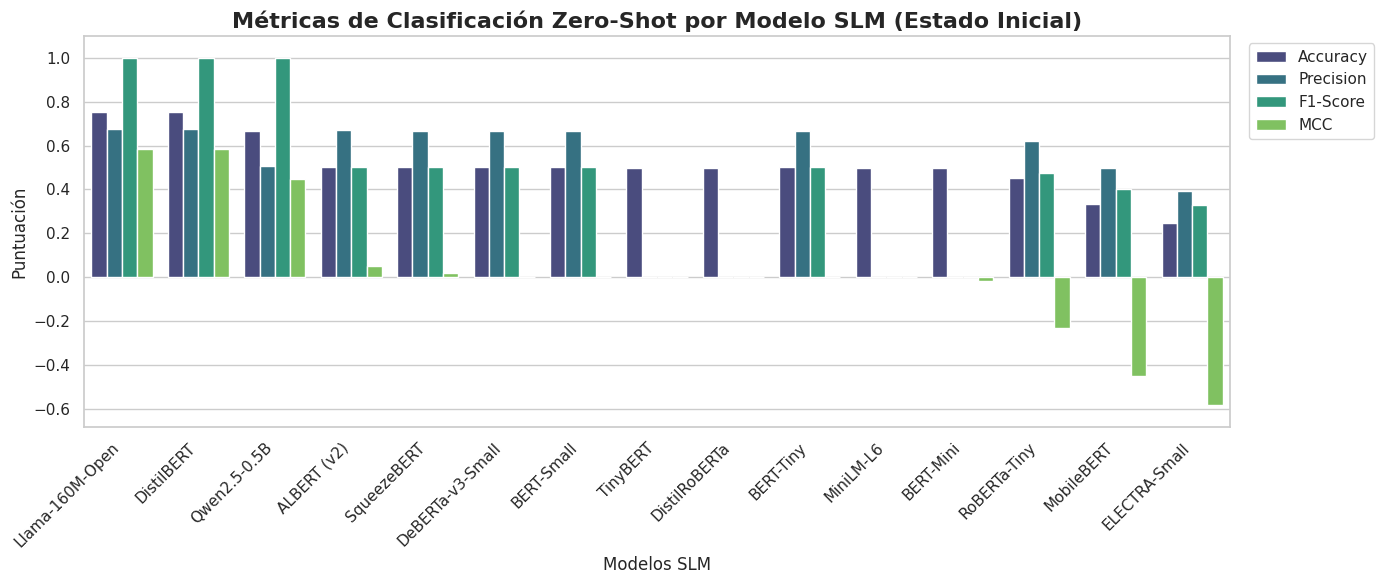

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display

# 1. Preparación de los datos extraídos
data_zs = {
    'Modelo': [
        "ALBERT (v2)", "BERT-Mini", "BERT-Small", "BERT-Tiny", "DeBERTa-v3-Small",
        "DistilBERT", "DistilRoBERTa", "ELECTRA-Small", "Llama-160M-Open", "MiniLM-L6",
        "MobileBERT", "Qwen2.5-0.5B", "RoBERTa-Tiny", "SqueezeBERT", "TinyBERT"
    ],
    'Accuracy': [0.5041, 0.4980, 0.5018, 0.5018, 0.5018, 0.7538, 0.4983, 0.2460, 0.7540, 0.4983, 0.3320, 0.6676, 0.4510, 0.5021, 0.4983],
    'Precision': [0.6693, 0.0000, 0.6682, 0.6682, 0.6682, 0.6752, 0.0000, 0.3946, 0.6754, 0.0000, 0.4985, 0.5053, 0.6216, 0.6684, 0.0000],
    'MCC': [0.0490, -0.0159, 0.0000, 0.0000, 0.0000, 0.5830, 0.0000, -0.5838, 0.5840, 0.0000, -0.4506, 0.4492, -0.2304, 0.0194, 0.0000],
    'F1-Score': [0.5029, 0.0000, 0.5018, 0.5018, 0.5018, 0.9981, 0.0000, 0.3304, 0.9995, 0.0000, 0.3999, 0.9978, 0.4751, 0.5019, 0.0000]
}

df_zs = pd.DataFrame(data_zs).sort_values(by='MCC', ascending=False)

# Configuración visual de Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# ==========================================
# 1. TABLA COMPARATIVA (Diseño del usuario)
# ==========================================
print("📊 RENDIMIENTO BASE (RESULTADOS ZERO-SHOT):")
# Nota: RAM, Storage e Infer se omiten aquí al ser datos constantes de arquitectura
# que no varían por fase en el benchmark previo.
display(df_zs.reset_index(drop=True))

# ==========================================
# 2. GRÁFICA DE MÉTRICAS (Diseño del usuario)
# ==========================================
fig, ax = plt.subplots(figsize=(14, 6))

# Transformar datos para Seaborn (Melt)
df_melted = df_zs.melt(id_vars='Modelo',
                       value_vars=['Accuracy', 'Precision', 'F1-Score', 'MCC'],
                       var_name='Métrica', value_name='Puntuación')

# Creación de la gráfica de barras con paleta viridis
sns.barplot(data=df_melted, x='Modelo', y='Puntuación', hue='Métrica', palette='viridis', ax=ax)

# Ajustes estéticos según tu diseño
ax.set_title('Métricas de Clasificación Zero-Shot por Modelo SLM (Estado Inicial)', fontsize=16, fontweight='bold')
ax.set_xlabel('Modelos SLM', fontsize=12)
ax.set_ylabel('Puntuación', fontsize=12)

# Ajustar límites para visualizar MCCs negativos
ax.set_ylim(df_melted['Puntuación'].min() - 0.1, 1.1)

# Rotación de etiquetas
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Leyenda fuera de la gráfica
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os, time, psutil, gc, glob
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, matthews_corrcoef, precision_score, f1_score
from transformers import AutoModel, AutoConfig
from peft import LoraConfig, get_peft_model, TaskType

# ==========================================
# 1. CONFIGURACIÓN COMPLETA
# ==========================================

#cambiar de UPD a TCP

FEATURES_UDP = [
    'HH_L5_weight',       # Conteo de paquetes (Persistencia)
    'HH_L3_weight',       # Conteo de paquetes ventana media
    'HH_jit_L3_mean',     # Promedio de jitter (automatización)
    'HH_jit_L1_mean',     # Jitter ventana corta
    'H_L5_weight',        # Volumen desde el Host
    'HH_L5_mean',         # Tamaño promedio de carga útil
    'HH_L3_std',          # Estabilidad del flujo
    'HH_jit_L5_variance', # Firma mecánica del bot
    'HH_L1_magnitude',    # Magnitud de relación Host-Host
    'HH_jit_L0.1_mean'    # Jitter instantáneo (escaneo rápido)
]

slm_benchmark_list = [
    {"name": "ALBERT (v2)", "id": "albert-base-v2"},
    {"name": "Qwen2.5-0.5B", "id": "Qwen/Qwen2.5-0.5B-Instruct"},
    {"name": "Llama-160M", "id": "Felladrin/Llama-160M-Chat-v1"},
    {"name": "TinyBERT", "id": "huawei-noah/TinyBERT_General_4L_312D"},
    {"name": "BERT-Mini", "id": "google/bert_uncased_L-4_H-256_A-4"},
    {"name": "ELECTRA-Small", "id": "google/electra-small-discriminator"},
    {"name": "RoBERTa-Tiny", "id": "arampacha/roberta-tiny"},
    {"name": "BERT-Tiny", "id": "prajjwal1/bert-tiny"},
    {"name": "MiniLM-L6", "id": "microsoft/MiniLM-L12-H384-uncased"},
    {"name": "DistilBERT", "id": "distilbert-base-uncased"},
    {"name": "SqueezeBERT", "id": "squeezebert/squeezebert-uncased"},
    {"name": "DeBERTa-v3-Small", "id": "microsoft/deberta-v3-small"},
    {"name": "DistilRoBERTa", "id": "distilroberta-base"},
    {"name": "BERT-Small", "id": "google/bert_uncased_L-6_H-512_A-8"}
]

# ==========================================
# 2. ARQUITECTURA UNIVERSAL
# ==========================================
class SLMEdgeMulticlass(nn.Module):
    def __init__(self, checkpoint, num_features, num_classes=3):
        super().__init__()
        self.config = AutoConfig.from_pretrained(checkpoint, trust_remote_code=True)
        self.transformer = AutoModel.from_pretrained(checkpoint, config=self.config, trust_remote_code=True)
        self.transformer = self.transformer.to(torch.float32)

        # Extracción segura de dimensiones (Soporta ALBERT, ELECTRA, Llama, etc.)
        self.hidden_size = getattr(self.config, "hidden_size", getattr(self.config, "d_model", 768))
        self.embed_size = getattr(self.config, "embedding_size", self.hidden_size)

        self.feature_projector = nn.Linear(1, self.embed_size).to(torch.float32)
        self.feature_embeddings = nn.Parameter(torch.randn(1, num_features, self.embed_size, dtype=torch.float32))

        self.classifier = nn.Sequential(
            nn.LayerNorm(self.hidden_size),
            nn.Linear(self.hidden_size, num_classes)
        ).to(torch.float32)

    def forward(self, x, noise_level=0.0):
        x = x.to(torch.float32)
        if self.training and noise_level > 0:
            x = x + torch.randn_like(x) * noise_level

        x = x.unsqueeze(-1)
        tokens = self.feature_projector(x)
        tokens = tokens + self.feature_embeddings

        outputs = self.transformer(inputs_embeds=tokens)

        # Extracción segura del hidden state
        if hasattr(outputs, 'last_hidden_state'):
            hidden_states = outputs.last_hidden_state
        else:
            hidden_states = outputs[0]

        pooled = hidden_states.mean(dim=1)
        return self.classifier(pooled)

# ==========================================
# 3. PREPARACIÓN DE DATOS
# ==========================================
def preparar_datos_multiclase(path):
    print("Cargando y etiquetando datos...")
    df_benign = pd.read_csv(os.path.join(path, '1.benign.csv'), usecols=FEATURES_UDP).sample(10000, random_state=42)
    df_benign['label'] = 0

    list_mirai = [pd.read_csv(f, usecols=FEATURES_UDP).sample(2500, random_state=42) for f in glob.glob(os.path.join(path, '1.mirai.*.csv'))]
    df_mirai = pd.concat(list_mirai) if list_mirai else pd.DataFrame()
    df_mirai['label'] = 1

    list_gafgyt = [pd.read_csv(f, usecols=FEATURES_UDP).sample(2500, random_state=42) for f in glob.glob(os.path.join(path, '1.gafgyt.*.csv'))]
    df_gafgyt = pd.concat(list_gafgyt) if list_gafgyt else pd.DataFrame()
    df_gafgyt['label'] = 2

    df = pd.concat([df_benign, df_mirai, df_gafgyt], ignore_index=True)
    labels = df.pop('label').values

    df = (df - df.min()) / (df.max() - df.min() + 1e-7)

    X_train, X_test, y_train, y_test = train_test_split(df.values, labels, test_size=0.2, random_state=42, stratify=labels)
    return (DataLoader(TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long()), batch_size=64, shuffle=True),
            DataLoader(TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long()), batch_size=128))

# ==========================================
# 4. CAPTURA DE MÉTRICAS
# ==========================================
def capturar_metricas(model, loader, device, nombre_modelo, fase, epoch=0):
    model.eval()
    y_true, y_pred = [], []
    mem_uso = psutil.Process().memory_info().rss / (1024 * 1024)
    param_size = sum(p.nelement() * p.element_size() for p in model.parameters()) / (1024 * 1024)

    inicio_t = time.perf_counter()
    with torch.no_grad():
        for bx, by in loader:
            outputs = model(bx.to(device))
            preds = torch.argmax(outputs, dim=1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(by.numpy())
    tiempo_ms = ((time.perf_counter() - inicio_t) / len(loader.dataset)) * 1000

    return {
        "Modelo": nombre_modelo, "Fase": fase, "Epoch": epoch,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        "F1-Score": round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        "MCC": round(matthews_corrcoef(y_true, y_pred), 4),
        "RAM_MB": round(mem_uso, 2), "Storage_MB": round(param_size, 2), "Infer_ms": round(tiempo_ms, 4)
    }

# ==========================================
# 5. EJECUCIÓN DEL BENCHMARK
# ==========================================
path = kagglehub.dataset_download("mkashifn/nbaiot-dataset")
train_loader, test_loader = preparar_datos_multiclase(path)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
historico_total = []

for slm in slm_benchmark_list:
    try:
        print(f"\n🚀 PROCESANDO: {slm['name']}")
        model = SLMEdgeMulticlass(slm['id'], len(FEATURES_UDP), num_classes=3).to(device)

        # La magia: "all-linear" hace que LoRA funcione en CUALQUIER arquitectura
        peft_config = LoraConfig(
            r=8, lora_alpha=32,
            target_modules="all-linear",
            task_type=TaskType.FEATURE_EXTRACTION
        )
        model.transformer = get_peft_model(model.transformer, peft_config)

        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(1, 4):
            model.train()
            for bx, by in train_loader:
                bx, by = bx.to(device), by.to(device)
                optimizer.zero_grad()
                outputs = model(bx, noise_level=0.01)
                loss = criterion(outputs, by)
                loss.backward()
                optimizer.step()

            res = capturar_metricas(model, test_loader, device, slm['name'], f"LoRA-Epoch-{epoch}", epoch)
            historico_total.append(res)
            print(f"✅ Epoch {epoch} | F1-Macro: {res['F1-Score']} | Infer: {res['Infer_ms']}ms")

        del model, optimizer
        gc.collect()
        torch.cuda.empty_cache()

    except Exception as e:
        print(f"❌ Error en {slm['name']}: {str(e)}")

pd.DataFrame(historico_total).to_csv("benchmark_iot_completo.csv", index=False)
print("\n✅ Benchmark guardado en 'benchmark_iot_completo.csv'")

Using Colab cache for faster access to the 'nbaiot-dataset' dataset.
Cargando y etiquetando datos...

🚀 PROCESANDO: ALBERT (v2)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

...

pytorch_model.bin:   0%|          | 0.00/141M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google/bert_uncased_L-6_H-512_A-8
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/141M [00:00<?, ?B/s]

✅ Epoch 1 | F1-Macro: 0.9549 | Infer: 0.1692ms
✅ Epoch 2 | F1-Macro: 0.9595 | Infer: 0.1734ms
✅ Epoch 3 | F1-Macro: 0.962 | Infer: 0.1699ms

✅ Benchmark guardado en 'benchmark_iot_completo.csv'


📊 RENDIMIENTO Y HARDWARE (RESULTADOS FINALES - EPOCH 3):


,Modelo,Accuracy,Precision,F1-Score,MCC,RAM_MB,Storage_MB,Infer_ms
0,Llama-160M,0.9666,0.9699,0.9684,0.9505,1665.09,532.34,0.9662
1,BERT-Small,0.9600,0.9621,0.9620,0.9399,1958.74,135.53,0.1699
2,DistilBERT,0.9584,0.9609,0.9609,0.9373,1721.50,255.74,0.3410
3,BERT-Mini,0.9581,0.9606,0.9605,0.9369,1742.20,43.21,0.0606
4,MiniLM-L6,0.9577,0.9603,0.9602,0.9363,1828.30,129.84,0.2356
5,DeBERTa-v3-Small,0.9573,0.9597,0.9597,0.9356,1962.71,541.61,0.8773
6,BERT-Tiny,0.9567,0.9589,0.9591,0.9348,1751.80,16.89,0.0408
7,RoBERTa-Tiny,0.9560,0.9582,0.9584,0.9337,1751.77,65.72,0.0603
8,ALBERT (v2),0.9553,0.9580,0.9580,0.9327,1474.53,45.09,0.7622
9,Qwen2.5-0.5B,0.9556,0.9581,0.9580,0.9332,1661.57,1901.42,2.8816


/tmp/ipykernel_4196/1052827989.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


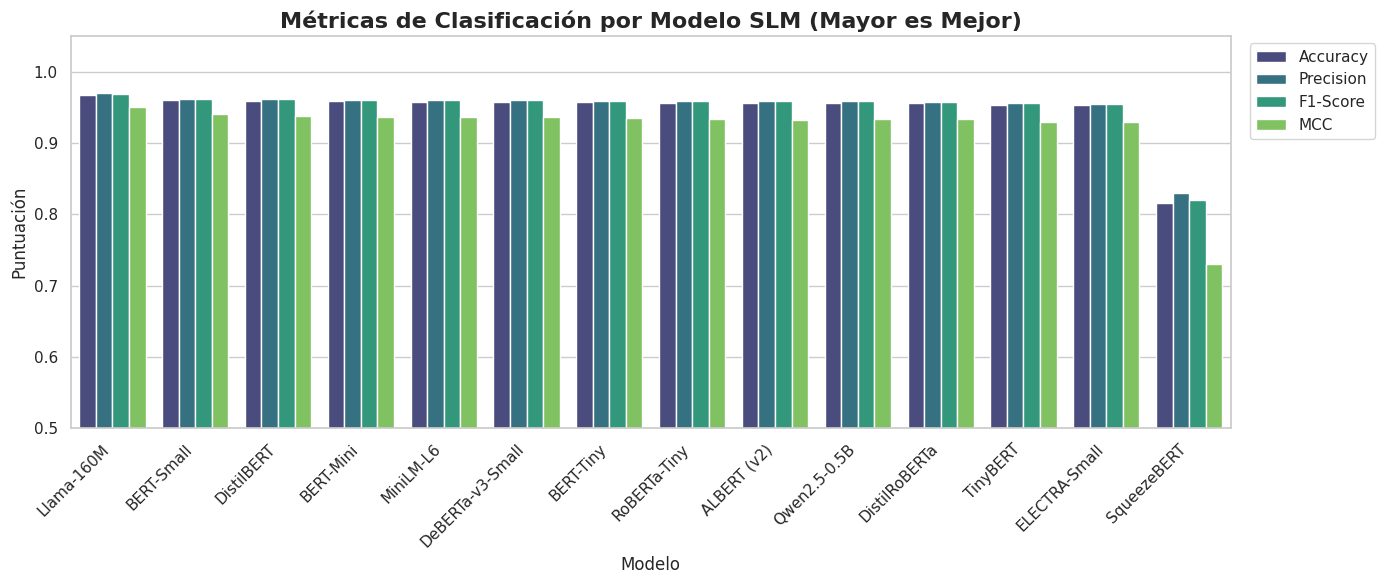

/tmp/ipykernel_4196/1052827989.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_4196/1052827989.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
/tmp/ipykernel_4196/1052827989.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')


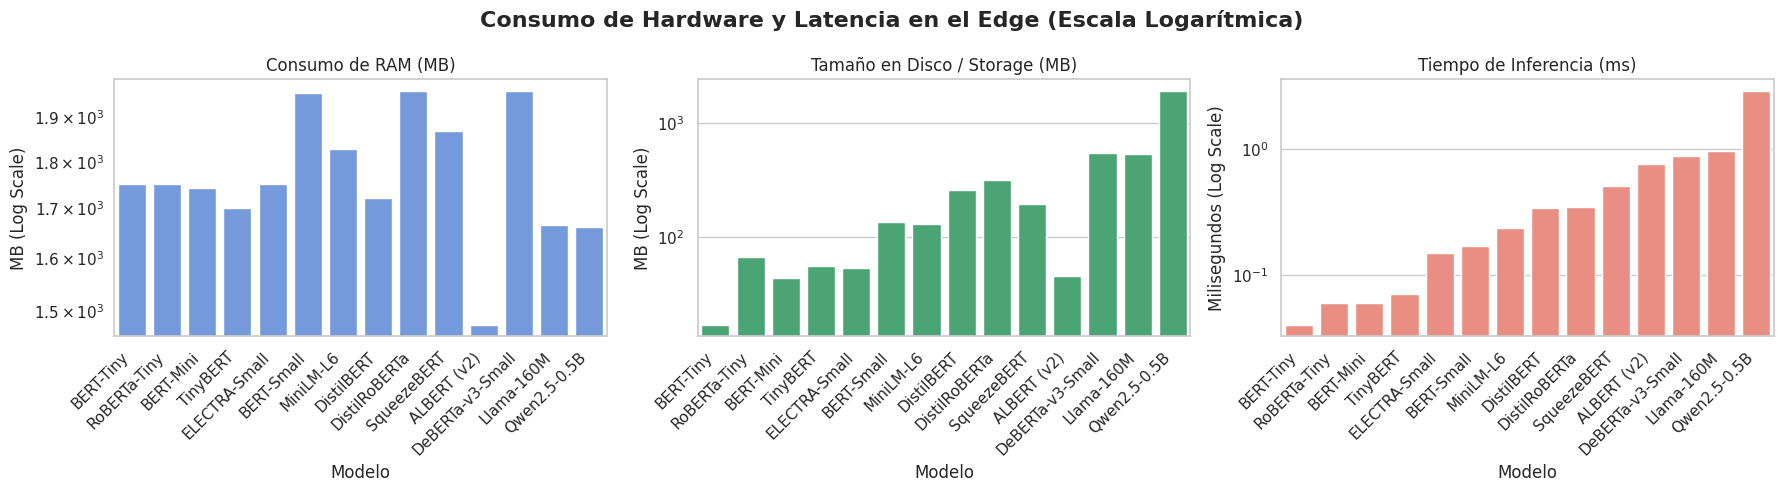

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Cargar los datos
df = pd.read_csv("benchmark_iot_completo.csv")

# Filtrar para quedarnos solo con el máximo rendimiento (Epoch 3)
df_final = df[df['Epoch'] == 3].sort_values(by='F1-Score', ascending=False)

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# ==========================================
# 1. TABLA COMPARATIVA
# ==========================================
print("📊 RENDIMIENTO Y HARDWARE (RESULTADOS FINALES - EPOCH 3):")
columnas_tabla = ['Modelo', 'Accuracy', 'Precision', 'F1-Score', 'MCC', 'RAM_MB', 'Storage_MB', 'Infer_ms']
display(df_final[columnas_tabla].reset_index(drop=True))

# ==========================================
# 2. GRÁFICA DE MÉTRICAS DEL MODELO
# ==========================================
fig, ax = plt.subplots(figsize=(14, 6))
df_melted_metrics = df_final.melt(id_vars='Modelo', value_vars=['Accuracy', 'Precision', 'F1-Score', 'MCC'],
                                  var_name='Métrica', value_name='Puntuación')

sns.barplot(data=df_melted_metrics, x='Modelo', y='Puntuación', hue='Métrica', palette='viridis', ax=ax)
ax.set_title('Métricas de Clasificación por Modelo SLM (Mayor es Mejor)', fontsize=16, fontweight='bold')
ax.set_ylim(0.5, 1.05)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==========================================
# 3. GRÁFICA DE HARDWARE (ESCALA LOGARÍTMICA)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Consumo de Hardware y Latencia en el Edge (Escala Logarítmica)', fontsize=16, fontweight='bold')

# Ordenar por el más rápido y ligero para las gráficas de hardware
df_hw = df_final.sort_values(by='Infer_ms')

# RAM Usage
sns.barplot(data=df_hw, x='Modelo', y='RAM_MB', ax=axes[0], color='cornflowerblue')
axes[0].set_yscale('log')
axes[0].set_title('Consumo de RAM (MB)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel('MB (Log Scale)')

# Storage
sns.barplot(data=df_hw, x='Modelo', y='Storage_MB', ax=axes[1], color='mediumseagreen')
axes[1].set_yscale('log')
axes[1].set_title('Tamaño en Disco / Storage (MB)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel('MB (Log Scale)')

# Inference Time
sns.barplot(data=df_hw, x='Modelo', y='Infer_ms', ax=axes[2], color='salmon')
axes[2].set_yscale('log')
axes[2].set_title('Tiempo de Inferencia (ms)')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
axes[2].set_ylabel('Milisegundos (Log Scale)')

plt.tight_layout()
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
"""Benchmark_SLM_Edge_IoT.ipynb"""

!pip install -q kagglehub transformers datasets peft accelerate scikit-learn psutil pandas numpy huggingface_hub

import kagglehub
import pandas as pd
import numpy as np
import os, time, psutil, gc, glob
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, matthews_corrcoef, precision_score, f1_score, recall_score
from sklearn.preprocessing import RobustScaler
from transformers import AutoModel, AutoConfig
from peft import LoraConfig, get_peft_model, TaskType
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from transformers import BitsAndBytesConfig

# === INYECCIÓN 1: AUTENTICACIÓN PARA MODELOS GATED (GEMMA) ===
from google.colab import userdata
from huggingface_hub import login
try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
    print("✅ Autenticación exitosa en HuggingFace. ¡Llave activa!")
except Exception as e:
    print("⚠️ Advertencia: No se encontró HF_TOKEN. Gemma podría fallar.")
# ==============================================================

# ==========================================
# 1. CONFIGURACIÓN COMPLETA (Top 15 Features)
# ==========================================
# Extraídas del Estudio de Ablación (Spearman + SHAP)
FEATURES_UNIVERSAL = [
    'HH_jit_L0.1_mean', 'MI_dir_L5_weight', 'H_L5_weight', 'HpHp_L0.01_radius',
    'HpHp_L0.01_std', 'HH_L0.1_radius', 'HH_L0.01_std', 'HH_L0.1_weight',
    'MI_dir_L0.1_mean', 'HH_jit_L5_mean', 'HpHp_L0.1_weight', 'HH_jit_L0.1_weight',
    'HH_L0.01_covariance', 'HpHp_L0.1_radius', 'HpHp_L5_magnitude'
]
vector = [
    {"name": "DistilRoBERTa", "id": "distilroberta-base"},
        # Familia BERT (Encoder-only)
    {"name": "DistilRoBERTa", "id": "distilroberta-base"},
    {"name": "DeBERTa-v3-Small", "id": "microsoft/deberta-v3-small"},
    {"name": "RoBERTa-Tiny", "id": "arampacha/roberta-tiny"},
    {"name": "BERT-Tiny", "id": "prajjwal1/bert-tiny"},
    {"name": "BERT-Mini", "id": "google/bert_uncased_L-4_H-256_A-4"},
        # Familia T5 (Encoder-Decoder)
    {"name": "Flan-T5-Small", "id": "google/flan-t5-small"},
    {"name": "TinyT5", "id": "google/t5-efficient-tiny"}
]
slm_benchmark_list = [

    {"name": "DistilRoBERTa", "id": "distilroberta-base"},
    # Familia Generativa (Decoder-only)
    {"name": "Qwen2.5-0.5B", "id": "Qwen/Qwen2.5-0.5B-Instruct"},
    {"name": "TinyLlama-1.1B", "id": "TinyLlama/TinyLlama-1.1B-Chat-v1.0"},
    {"name": "Phi-1.5", "id": "microsoft/phi-1_5"},
    {"name": "SmolLM-360M", "id": "HuggingFaceTB/SmolLM-360M-Instruct"},
    #{"name": "Gemma-2-2B", "id": "google/gemma-2-2b-it"},
    #{"name": "Danube3-500M", "id": "h2oai/h2o-danube3-500m-chat"},


]

# ==========================================
# 2. ARQUITECTURA UNIVERSAL SLM (CORREGIDA)
# ==========================================
class SLMEdgeMulticlass(nn.Module):
    def __init__(self, checkpoint, num_features, num_classes=3, quantize=False): # <-- CORRECCIÓN: Añadido quantize=False
        super().__init__()

        # Configuración de Cuantización
        bnb_config = None
        if quantize:
            bnb_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.float16,
                bnb_4bit_use_double_quant=True,
            )

        self.config = AutoConfig.from_pretrained(checkpoint, trust_remote_code=True)

        if getattr(self.config, "pad_token_id", None) is None:
            self.config.pad_token_id = getattr(self.config, "eos_token_id", 0)

        # Carga del modelo
        self.transformer = AutoModel.from_pretrained(
            checkpoint,
            config=self.config,
            trust_remote_code=True,
            quantization_config=bnb_config,
            device_map="auto" if quantize else None
        )

        # CORRECCIÓN: Solo pasar a float32 si NO está cuantizado
        if not quantize:
            self.transformer = self.transformer.to(torch.float32)

        self.hidden_size = getattr(self.config, "hidden_size", getattr(self.config, "d_model", 768))
        self.embed_size = getattr(self.config, "embedding_size", self.hidden_size)

        # Estas capas se mantienen en float32 para estabilidad
        self.feature_projector = nn.Linear(1, self.embed_size).to(torch.float32)
        self.feature_embeddings = nn.Parameter(torch.randn(1, num_features, self.embed_size, dtype=torch.float32))

        self.classifier = nn.Sequential(
            nn.LayerNorm(self.hidden_size),
            nn.Linear(self.hidden_size, num_classes)
        ).to(torch.float32)

    def forward(self, x, noise_level=0.0):
        # CORRECCIÓN: Detectar el dtype del transformer (float16 en QLoRA, float32 en Normal)
        target_dtype = next(self.transformer.parameters()).dtype

        x = x.to(torch.float32)
        if self.training and noise_level > 0:
            x = x + torch.randn_like(x) * noise_level

        x = x.unsqueeze(-1)

        # Proyectar y sumar (en float32) y luego pasar al dtype del modelo
        tokens = self.feature_projector(x) + self.feature_embeddings
        tokens = tokens.to(target_dtype)

        if getattr(self.config, "is_encoder_decoder", False):
            outputs = self.transformer.encoder(inputs_embeds=tokens)
        else:
            outputs = self.transformer(inputs_embeds=tokens)

        if hasattr(outputs, 'last_hidden_state'):
            hidden_states = outputs.last_hidden_state
        else:
            hidden_states = outputs[0]

        # Volver a float32 para el clasificador final
        pooled = hidden_states.mean(dim=1).to(torch.float32)
        return self.classifier(pooled)

# ==========================================
# 3. PREPARACIÓN DE DATOS (MUESTREO SEGURO EN DISCO)
# ==========================================
def preparar_datos_benchmark_general(path, muestras_benign=30000, muestras_ataque=10000):
    print("Extrayendo datos de forma segura en disco (evitando OOM en RAM)...")

    def cargar_seguro(patron, label, total_muestras_deseadas):
        archivos = glob.glob(os.path.join(path, '**', patron), recursive=True)
        if not archivos: archivos = glob.glob(os.path.join(path, patron))
        if not archivos: return pd.DataFrame()

        muestras_por_archivo = total_muestras_deseadas // len(archivos)
        lista_dfs = []

        for f in archivos:
            try:
                total_rows = sum(1 for _ in open(f, 'r')) - 1
                if total_rows > muestras_por_archivo:
                    skip = sorted(np.random.choice(range(1, total_rows + 1), total_rows - muestras_por_archivo, replace=False))
                    df_temp = pd.read_csv(f, usecols=FEATURES_UNIVERSAL, skiprows=skip).dropna()
                else:
                    df_temp = pd.read_csv(f, usecols=FEATURES_UNIVERSAL).dropna()
                lista_dfs.append(df_temp)
            except: pass

        if lista_dfs:
            df_final = pd.concat(lista_dfs, ignore_index=True)
            df_final['label'] = label
            return df_final
        return pd.DataFrame()

    print("Procesando Benigno...")
    df_benign = cargar_seguro('*.benign.csv', 0, muestras_benign)
    print("Procesando Mirai...")
    df_mirai = cargar_seguro('*.mirai.*.csv', 1, muestras_ataque)
    print("Procesando Gafgyt...")
    df_gafgyt = cargar_seguro('*.gafgyt.*.csv', 2, muestras_ataque)

    df_total = pd.concat([df_benign, df_mirai, df_gafgyt], ignore_index=True)
    print(f"\nTotal Dataset Consolidado: {len(df_total)} muestras")
    print(df_total['label'].value_counts())

    labels = df_total.pop('label').values

    # DIVISIÓN TRAIN/TEST (Antes de escalar para evitar fuga de datos)
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        df_total.values, labels, test_size=0.2, random_state=42, stratify=labels
    )

    # ESCALADO ROBUSTO (Protección contra outliers)
    print("\nAplicando RobustScaler...")
    scaler = RobustScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    train_loader = DataLoader(TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long()), batch_size=64, shuffle=True)
    test_loader = DataLoader(TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long()), batch_size=128, shuffle=False)

    return train_loader, test_loader

# ==========================================
# 4. CAPTURA DE MÉTRICAS NEUTRALES
# ==========================================
def capturar_metricas(model, loader, device, nombre_modelo, fase, epoch=0):
    model.eval()
    y_true, y_pred = [], []
    mem_uso = psutil.Process().memory_info().rss / (1024 * 1024)
    param_size = sum(p.nelement() * p.element_size() for p in model.parameters()) / (1024 * 1024)

    inicio_t = time.perf_counter()
    with torch.no_grad():
        for bx, by in loader:
            outputs = model(bx.to(device))
            preds = torch.argmax(outputs, dim=1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(by.numpy())
    tiempo_ms = ((time.perf_counter() - inicio_t) / len(loader.dataset)) * 1000

    return {
        "Modelo": nombre_modelo, "Fase": fase, "Epoch": epoch,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        "F1-Macro": round(f1_score(y_true, y_pred, average='macro', zero_division=0), 4),
        "MCC": round(matthews_corrcoef(y_true, y_pred), 4),
        "RAM_MB": round(mem_uso, 2), "Storage_MB": round(param_size, 2), "Infer_ms": round(tiempo_ms, 4)
    }

# ==========================================
# 5. MOTOR DEL BENCHMARK (COMPARATIVA LORA VS QLORA)
# ==========================================
print("Iniciando descarga de N-BaIoT...")
path = kagglehub.dataset_download("mkashifn/nbaiot-dataset")
train_loader, test_loader = preparar_datos_benchmark_general(path, muestras_benign=30000, muestras_ataque=10000)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
historico_total = []

# Bucle externo para comparar ambos estados: Normal vs Cuantizado
for modo_cuantizacion in [False, True]:
    estado_txt = "4-bit (QLoRA)" if modo_cuantizacion else "Full (LoRA)"

    for slm in slm_benchmark_list:
        try:
            nombre_reporte = f"{slm['name']}"
            print(f"\n🚀 EVALUANDO: {nombre_reporte} | MODO: {estado_txt}")

            # 1. Cargar el modelo (La base se carga cuantizada si modo_cuantizacion=True)
            model = SLMEdgeMulticlass(slm['id'], len(FEATURES_UNIVERSAL), num_classes=3, quantize=modo_cuantizacion).to(device)

            # 2. "Puente": Preparar para entrenamiento en baja precisión (Solo si es QLoRA)
            if modo_cuantizacion:
                from peft import prepare_model_for_kbit_training
                model.transformer = prepare_model_for_kbit_training(model.transformer)

            # 3. Inyección de LoRA (Se aplica sobre la base ya definida)
            peft_config = LoraConfig(
                r=8, lora_alpha=32, lora_dropout=0.05, bias="none",
                target_modules="all-linear", task_type=TaskType.FEATURE_EXTRACTION
            )
            model.transformer = get_peft_model(model.transformer, peft_config)

            optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
            criterion = nn.CrossEntropyLoss()

            # Bucle de entrenamiento
            for epoch in range(1, 2):
                model.train()
                for bx, by in train_loader:
                    bx, by = bx.to(device), by.to(device)
                    optimizer.zero_grad()
                    # En modo QLoRA el forward maneja automáticamente el cast de tipos
                    outputs = model(bx, noise_level=0.01)
                    loss = criterion(outputs, by)
                    loss.backward()
                    optimizer.step()

                # Captura de todas las métricas (Añadimos 'Modo' para las gráficas)
                res = capturar_metricas(model, test_loader, device, nombre_reporte, estado_txt, epoch)
                historico_total.append(res)
                print(f"✅ {estado_txt} - Epoch {epoch} | F1: {res['F1-Macro']} | RAM: {res['RAM_MB']} MB")

            # Limpieza de memoria tras cada configuración
            del model, optimizer
            gc.collect()
            torch.cuda.empty_cache()

        except Exception as e:
            print(f"❌ Error en {slm['name']} ({estado_txt}): {str(e)}")
            gc.collect()
            torch.cuda.empty_cache()

# Al finalizar, el dataframe 'df_final' tendrá duplicadas las entradas por modelo:
# Una para 'Full (LoRA)' y otra para '4-bit (QLoRA)', permitiendo comparar en las gráficas.

# Guardar Resultados
df_final = pd.DataFrame(historico_total)
nombre_archivo_csv = "benchmark_iot_final.csv"
df_final.to_csv(nombre_archivo_csv, index=False)
print(f"\n✅ Benchmark consolidado. Revisa el archivo '{nombre_archivo_csv}'")

# ==========================================
# 6. GRÁFICAS DE ANÁLISIS
# ==========================================
# Cargar los datos generados para evitar fallos si se ejecuta en otra celda
df = pd.read_csv(nombre_archivo_csv)

# Filtrar para quedarnos solo con el máximo rendimiento (Epoch 3)
df_final_graficas = df[df['Epoch'] == 3].sort_values(by='F1-Macro', ascending=False)

sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

print("\n📊 RENDIMIENTO Y HARDWARE (RESULTADOS FINALES - EPOCH 3):")
columnas_tabla = ['Modelo', 'Accuracy', 'Precision', 'F1-Macro', 'MCC', 'RAM_MB', 'Storage_MB', 'Infer_ms']
display(df_final_graficas[columnas_tabla].reset_index(drop=True))

fig, ax = plt.subplots(figsize=(14, 6))
df_melted_metrics = df_final_graficas.melt(id_vars='Modelo', value_vars=['Accuracy', 'Precision', 'F1-Macro', 'MCC'],
                                  var_name='Métrica', value_name='Puntuación')

sns.barplot(data=df_melted_metrics, x='Modelo', y='Puntuación', hue='Métrica', palette='viridis', ax=ax)
ax.set_title('Métricas de Clasificación por Modelo SLM (Mayor es Mejor)', fontsize=16, fontweight='bold')
ax.set_ylim(0.5, 1.05)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Consumo de Hardware y Latencia en el Edge (Escala Logarítmica)', fontsize=16, fontweight='bold')

df_hw = df_final_graficas.sort_values(by='Infer_ms')

sns.barplot(data=df_hw, x='Modelo', y='RAM_MB', ax=axes[0], color='cornflowerblue')
axes[0].set_yscale('log')
axes[0].set_title('Consumo de RAM (MB)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_ylabel('MB (Log Scale)')

sns.barplot(data=df_hw, x='Modelo', y='Storage_MB', ax=axes[1], color='mediumseagreen')
axes[1].set_yscale('log')
axes[1].set_title('Tamaño en Disco / Storage (MB)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].set_ylabel('MB (Log Scale)')

sns.barplot(data=df_hw, x='Modelo', y='Infer_ms', ax=axes[2], color='salmon')
axes[2].set_yscale('log')
axes[2].set_title('Tiempo de Inferencia (ms)')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
axes[2].set_ylabel('Milisegundos (Log Scale)')

plt.tight_layout()
plt.show()

✅ Autenticación exitosa en HuggingFace. ¡Llave activa!
Iniciando descarga de N-BaIoT...
Using Colab cache for faster access to the 'nbaiot-dataset' dataset.
Extrayendo datos de forma segura en disco (evitando OOM en RAM)...
Procesando Benigno...
Procesando Mirai...
Procesando Gafgyt...

Total Dataset Consolidado: 49962 muestras
label
0    29997
2     9990
1     9975
Name: count, dtype: int64

Aplicando RobustScaler...

🚀 EVALUANDO: DistilRoBERTa | MODO: Full (LoRA)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: distilroberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Full (LoRA) - Epoch 1 | F1: 0.9161 | RAM: 2222.2 MB

🚀 EVALUANDO: Qwen2.5-0.5B | MODO: Full (LoRA)


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]